импорт и установка необходимых библиотек

In [ ]:
!pip install xgboost catboost optuna
!pip install optuna-integration

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import pandas as pd
from sklearn.impute import SimpleImputer
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd
from xgboost import XGBClassifier
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from optuna.integration import XGBoostPruningCallback
from optuna.integration import CatBoostPruningCallback
from joblib import Parallel, delayed

/Users/kirillgorunov/miniconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
optuna.logging.set_verbosity(optuna.logging.WARNING) 

чтение данных локально (возникали проблемы с чтением из удаленной postgres)

In [2]:
UNITS_DIR = Path('units')
ICD_DIR = Path('icd10_oncology_codes')

In [4]:
laboratory_tests = pd.read_csv(
    UNITS_DIR / 'laboratory_tests.tsv', sep='\t',
    parse_dates=['test_date'],
)
print('laboratory_tests:', laboratory_tests.shape)

patients_raw = pd.read_csv(
    UNITS_DIR / 'patients.tsv', sep='\t',
    parse_dates=['birth_date', 'death_date'],
)
print('patients_raw:', patients_raw.shape)

diagnoses = pd.read_csv(
    ICD_DIR / 'diagnoses.tsv', sep='\t',
    parse_dates=['diag_establish_date'],
)
print('diagnoses:', diagnoses.shape)

surgeries = pd.read_csv(
    UNITS_DIR / 'surgeries.tsv', sep='\t',
    parse_dates=['surgery_date'],
)
print('surgeries:', surgeries.shape)
radiotherapy = pd.read_csv(
    UNITS_DIR / 'radiotherapy.tsv', sep='\t',
    parse_dates=['start_date', 'end_date'],
)
print('radiotherapy:', radiotherapy.shape)

laboratory_tests: (17718890, 6)
patients_raw: (32500, 5)
diagnoses: (33370, 14)
surgeries: (20783, 7)
radiotherapy: (10147, 6)


Отображаем явные выбросы по медицинским данным

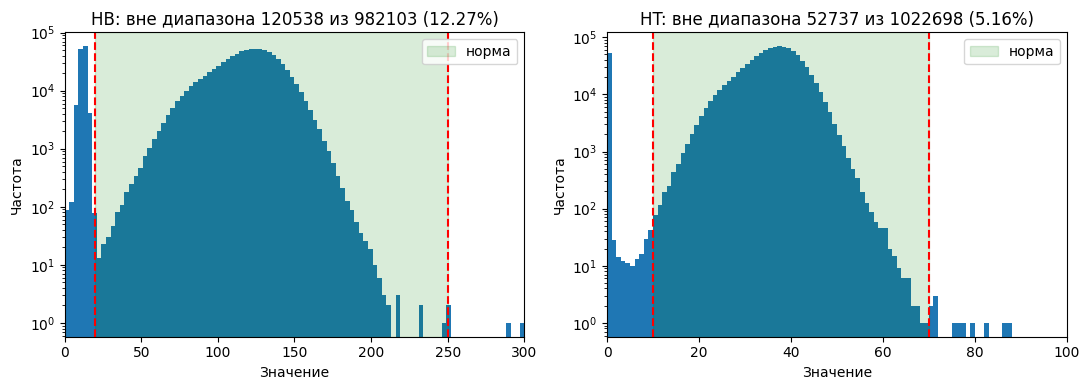

In [ ]:
lab = laboratory_tests[laboratory_tests['test_type_code'].isin(['HB', 'HT'])].copy()
lab['test_result'] = pd.to_numeric(lab['test_result'], errors='coerce')

ranges = {'HB': (20, 250),'HT': (10, 70)}
xlims  = {'HB': (0, 300), 'HT': (0, 100)}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, code in zip(axes, ['HB', 'HT']):
    vals = lab.loc[lab['test_type_code'] == code, 'test_result'].dropna()
    lo, hi = ranges[code]

    ax.hist(vals, bins=100, range=xlims[code])
    ax.axvspan(lo, hi, color='green', alpha=0.15, label='норма')
    ax.axvline(lo, color='red', ls='--')
    ax.axvline(hi, color='red', ls='--')

    n_bad = ((vals < lo) | (vals > hi)).sum()
    ax.set_title(f'{code}: вне диапазона {n_bad} из {len(vals)} '
                 f'({n_bad/len(vals)*100:.2f}%)')
    ax.set_xlabel('Значение')
    ax.set_ylabel('Частота')
    ax.set_xlim(xlims[code])
    ax.set_yscale('log')
    ax.legend()
plt.tight_layout()
plt.show()

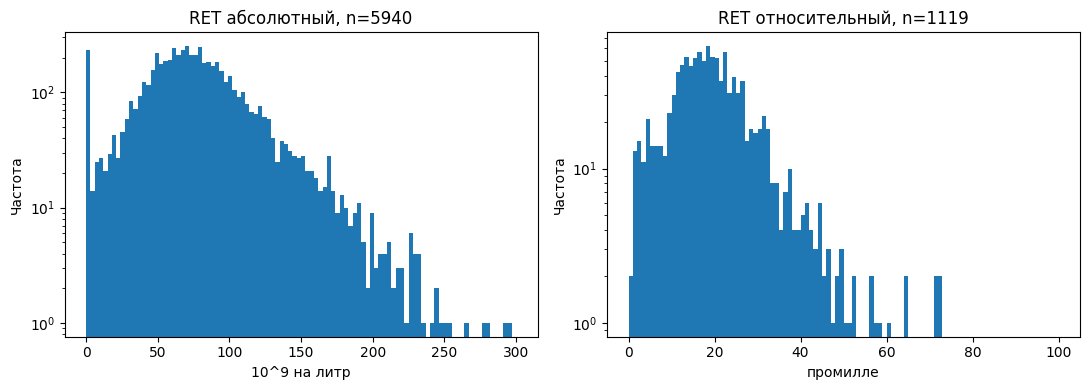

In [ ]:
ret = laboratory_tests[laboratory_tests['test_type_code'] == 'RET'].copy()
ret['v'] = pd.to_numeric(ret['test_result'], errors='coerce')
u = ret['value_unit_code']

abs_vals = pd.concat([
    ret.loc[u == 'x10e9_l',  'v'],
    ret.loc[u == 'x10e12_l', 'v'] * 1000,
]).dropna()

rel_vals = ret.loc[u == '%o', 'v'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(abs_vals, bins=100, range=(0, 300))
axes[0].set_title(f'RET абсолютный, n={len(abs_vals)}')
axes[0].set_xlabel('10^9 на литр')

axes[1].hist(rel_vals, bins=100, range=(0, 100))
axes[1].set_title(f'RET относительный, n={len(rel_vals)}')
axes[1].set_xlabel('промилле')

for ax in axes:
    ax.set_ylabel('Частота')
    ax.set_yscale('log')
plt.tight_layout()

Нормализуем значения из таблицы

для этого воспользуемся переводом данных из одной системы в другую (приложено из данных)

In [ ]:
HB_FACTOR = {"g_l": 1.0, "g_dl": 10.0}
HT_FACTOR = {"percent": 1.0, "l_l": 100.0}

laboratory_tests["value_unit_code"] = laboratory_tests["value_unit_code"].fillna("")
laboratory_tests["test_result"] = pd.to_numeric(laboratory_tests["test_result"], errors="coerce")

def normalize_hb(value, unit):
    if unit in HB_FACTOR:
        return value * HB_FACTOR[unit]
    if unit == "":
        return value * (10.0 if value < 30 else 1.0)
    return np.nan

def normalize_ht(value, unit):
    if unit == "percent":
        return value
    if unit in ("l_l", ""):
        return value * 100.0 if value < 1 else value
    return np.nan

RANGES = {"HB": (20.0, 250.0), "HT": (5.0, 70.0)}

for code, fn in [("HB", normalize_hb), ("HT", normalize_ht)]:
    mask = laboratory_tests["test_type_code"] == code
    lo, hi = RANGES[code]
    v = laboratory_tests.loc[mask].apply(
        lambda r: fn(r["test_result"], r["value_unit_code"]), axis=1)
    v = v.where((v >= lo) & (v <= hi))
    laboratory_tests.loc[mask, "test_result"] = v

laboratory_tests.loc[laboratory_tests.test_type_code.eq("HB"), "value_unit_code"] = "g_l"
laboratory_tests.loc[laboratory_tests.test_type_code.eq("HT"), "value_unit_code"] = "percent"


for code in ["HB", "HT"]:
    s = laboratory_tests.loc[laboratory_tests.test_type_code == code, "test_result"].dropna()
    n_total = (laboratory_tests.test_type_code == code).sum()
    print(code, "осталось: ", len(s), "медиана:", s.median())


HB осталось:  980428 медиана: 120.0
HT осталось:  1021134 медиана: 36.4


нормилизация RET

In [ ]:
def normalize_ret_abs(value):
    if pd.isna(value): 
        return np.nan
    if value < 1:
        return value * 1000
    if value >= 10:
        return value
    return np.nan

m_ret = laboratory_tests["test_type_code"].eq("RET")
is_pct = m_ret & laboratory_tests["value_unit_code"].eq("%o")
is_abs = m_ret & ~laboratory_tests["value_unit_code"].eq("%o")

v_pct = pd.to_numeric(laboratory_tests.loc[is_pct, "test_result"], errors="coerce")
v_pct = v_pct.where((v_pct >= 0) & (v_pct <= 200))
laboratory_tests.loc[is_pct, "test_result"] = v_pct
laboratory_tests.loc[is_pct, "test_type_code"] = "RET_pct"
laboratory_tests.loc[is_pct, "value_unit_code"] = "%o"

v_abs = pd.to_numeric(laboratory_tests.loc[is_abs, "test_result"], errors="coerce").map(normalize_ret_abs)
v_abs = v_abs.where((v_abs >= 0) & (v_abs <= 500))
laboratory_tests.loc[is_abs, "test_result"] = v_abs
laboratory_tests.loc[is_abs, "test_type_code"] = "RET_abs"
laboratory_tests.loc[is_abs, "value_unit_code"] = "x10e9_l"

for code in ["RET_abs", "RET_pct"]:
    s = laboratory_tests.loc[laboratory_tests.test_type_code.eq(code), "test_result"].dropna()
    print(code, "n=", len(s), "медиана=", s.median(), 2)

RET_abs n= 6878 медиана= 75.3
RET_pct n= 1119 медиана= 18.6


остальные данные были в корректных шкалах, из них уберем выбросы:

In [ ]:
RANGES = {
    "ТРОМБОЦИТЫ": (1, 2000),
    "ЛИМФОЦИТЫ": (0, 100),
    "WBC": (0, 500),
    "RBC": (1, 9),
    "MPV": (4, 20),
    "МОНОЦИТЫ": (0, 50),
    "ЭОЗИНОФИЛЫ": (0, 50),
    "БАЗОФИЛЫ": (0, 20),
    "НЕЙТРОФИЛЫ": (0, 200),
    "КРЕАТИНИН": (10, 2000),
    "АЛТ": (1, 5000),
    "АСТ": (1, 5000),
    "ОБЩИЙ БИЛИРУБИН": (1, 1000),
    "МОЧЕВИНА": (0.5, 100), 
    "ОБЩИЙ БЕЛОК": (20, 120),
    "ЩФ": (10, 5000),
    "КАЛИЙ": (1.5, 9),
    "НАТРИЙ": (100, 180),
    "СОЭ": (0, 150),
    "ЖЕЛЕЗО": (0.5, 100),
    "КАЛЬЦИЙ ОБЩИЙ": (1, 5),
    "ЛДГ": (50, 20000),
    "АЛЬБУМИН": (10, 70),
    "ХЛОР": (70, 140),
    "ХОЛЕСТЕРИН ОБЩИЙ": (1, 30),
    "ГГТ": (1, 5000),
    "ГЛЮКОЗА": (1, 50),
    "АМИЛАЗА": (0, 5000),
    "ТРИГЛИЦЕРИДЫ": (0.1, 50)
}

laboratory_tests["test_result"] = pd.to_numeric(laboratory_tests["test_result"], errors="coerce")

for code, (lo, hi) in RANGES.items():
    m = laboratory_tests["test_type_code"].eq(code)
    v = laboratory_tests.loc[m, "test_result"]
    laboratory_tests.loc[m, "test_result"] = v.where((v >= lo) & (v <= hi))

for code in RANGES:
    m = laboratory_tests.test_type_code.eq(code)
    n = int(m.sum()); kept = int(laboratory_tests.loc[m,"test_result"].notna().sum())
    print(f"{code} оставлено {kept}/{n}  выброшено {n-kept}")

ТРОМБОЦИТЫ         оставлено 1074343/1074710  выброшено 367
ЛИМФОЦИТЫ          оставлено 1006113/1006123  выброшено 10
WBC                оставлено 987076/987079  выброшено 3
RBC                оставлено 982181/982444  выброшено 263
MPV                оставлено 971277/972195  выброшено 918
МОНОЦИТЫ           оставлено 968135/968150  выброшено 15
ЭОЗИНОФИЛЫ         оставлено 880532/880533  выброшено 1
БАЗОФИЛЫ           оставлено 863468/863471  выброшено 3
НЕЙТРОФИЛЫ         оставлено 805259/805259  выброшено 0
КРЕАТИНИН          оставлено 826184/826405  выброшено 221
АЛТ                оставлено 793232/793379  выброшено 147
АСТ                оставлено 790719/790841  выброшено 122
ОБЩИЙ БИЛИРУБИН    оставлено 765276/765428  выброшено 152
МОЧЕВИНА           оставлено 728552/728782  выброшено 230
ОБЩИЙ БЕЛОК        оставлено 720386/720515  выброшено 129
ЩФ                 оставлено 439538/439667  выброшено 129
КАЛИЙ              оставлено 304518/305081  выброшено 563
НАТРИЙ             о

Логика отбора данных и построение датасета с целевой переменной

Отображена подробно в текстовой работе

In [5]:
def create_dataset_offset(offset):
    lt = laboratory_tests.dropna(subset=['test_type_code']).copy()
    lt['test_result'] = pd.to_numeric(lt['test_result'], errors='coerce')
    lt = lt.dropna(subset=['test_result'])

    pats = (
        patients_raw[['patient_id', 'birth_date', 'death_date']]
        .drop_duplicates(subset='patient_id')
        .copy()
    )

    df = lt.merge(pats, on='patient_id', how='inner')

    df['target'] = df['death_date'].notna().astype(int)

    df['days_to_death'] = (df['death_date'] - df['test_date']).dt.days

    last_test_date = df.groupby('patient_id')['test_date'].transform('max')

    mask_dead = (
        (df['target'] == 1)
        & (df['days_to_death'] >= 30 * offset)
        & (df['days_to_death'] <= 30 * offset + 30)
    )

    mask_alive = (
        (df['target'] == 0)
        & (df['test_date'] >= last_test_date - pd.Timedelta(days=30))
        & (df['test_date'] <= last_test_date)
    )

    base = df[mask_dead | mask_alive].copy()

    if base.empty:
        return pd.DataFrame()

    # референсная дата
    patient_ref = (
        base.groupby('patient_id')['test_date']
        .max()
        .rename('ref_date')
        .reset_index()
    )

    base = base.merge(patient_ref, on='patient_id', how='left')

    base['days_before'] = (base['ref_date'] - base['test_date']).dt.days

    base_sorted = base.sort_values(['patient_id', 'test_type_code', 'test_date'])

    last_val = (
        base_sorted
        .groupby(['patient_id', 'test_type_code'])['test_result']
        .last()
        .rename('last_val')
    )

    first_val = (
        base_sorted
        .groupby(['patient_id', 'test_type_code'])['test_result']
        .first()
        .rename('first_val')
    )

    agg_stats = (
        base.groupby(['patient_id', 'test_type_code'])['test_result']
        .agg(
            mean_all='mean',
            std_all='std',
            count_all='count'
        )
        .round(4)
    )

    def window_mean(days, name):
        return (
            base[base['days_before'] <= days]
            .groupby(['patient_id', 'test_type_code'])['test_result']
            .mean()
            .round(4)
            .rename(name)
        )

    def window_percentile(days, q, name):
        return (
            base[base['days_before'] <= days]
            .groupby(['patient_id', 'test_type_code'])['test_result']
            .quantile(q)
            .round(4)
            .rename(name)
        )

    # глобальный перцентиль
    base['pct_rank'] = base.groupby('test_type_code')['test_result'].rank(pct=True)
 
    mean_pct_rank = (
        base.groupby(['patient_id', 'test_type_code'])['pct_rank']
        .mean()
        .round(4)
        .rename('mean_pct_rank')
    )

    agg = pd.concat([
        last_val,
        first_val,
        agg_stats,
        window_mean(7, 'mean_7d'),
        window_percentile(30, 0.25, 'perc_25'),
        window_percentile(30, 0.50, 'perc_50'),
        window_percentile(30, 0.75, 'perc_75'),
        mean_pct_rank
    ], axis=1).reset_index()

    feat_cols = [
        'last_val',
        'first_val',
        'mean_all',
        'std_all',
        'count_all',
        'mean_7d',
        'perc_25',
        'perc_50',
        'perc_75',
        'mean_pct_rank'
    ]

    wide_parts = []

    for feat in feat_cols:
        piv = agg.pivot(
            index='patient_id',
            columns='test_type_code',
            values=feat
        )
        piv.columns = [f'{c}_{feat}' for c in piv.columns]
        wide_parts.append(piv)

    lab_features = pd.concat(wide_parts, axis=1).reset_index()

    patient_info = (
        base[['patient_id', 'birth_date', 'death_date', 'target', 'ref_date']]
        .drop_duplicates(subset='patient_id')
        .copy()
    )

    patient_info['age'] = (
        (patient_info['ref_date'] - patient_info['birth_date']).dt.days / 365.25
    ).round(2)


    # категориальные признаки
    def multihot_before_ref(df_cat, code_col, date_col, prefix, min_count=10):
        d = df_cat[['patient_id', code_col, date_col]].copy()

        d = d.dropna(subset=['patient_id', code_col, date_col])

        d = d.merge(
            patient_info[['patient_id', 'ref_date']],
            on='patient_id',
            how='inner'
        )

        d = d[d[date_col] <= d['ref_date']].copy()

        d = d[['patient_id', code_col]].drop_duplicates()

        keep = d[code_col].value_counts()
        keep = keep[keep >= min_count].index

        d = d[d[code_col].isin(keep)]

        if d.empty:
            return pd.DataFrame({'patient_id': patient_info['patient_id'].unique()})

        hot = (
            d.assign(_value=1)
            .pivot_table(
                index='patient_id',
                columns=code_col,
                values='_value',
                aggfunc='max',
                fill_value=0
            )
            .astype('int8')
        )

        hot.columns = [f'{prefix}_{col}' for col in hot.columns]

        return hot.reset_index()

    diag_hot = multihot_before_ref(
        df_cat=diagnoses,
        code_col='diag_code',
        date_col='diag_establish_date',
        prefix='diag',
        min_count=10
    )

    surgery_hot = multihot_before_ref(
        df_cat=surgeries,
        code_col='surgery_code',
        date_col='surgery_date',
        prefix='surgery',
        min_count=10
    )

    therapy_hot = multihot_before_ref(
        df_cat=radiotherapy,
        code_col='therapy_kind',
        date_col='start_date',
        prefix='rt',
        min_count=10
    )

    df_model = (
        patient_info[['patient_id', 'age', 'target']]
        .merge(lab_features, on='patient_id', how='inner')
        .merge(diag_hot, on='patient_id', how='left')
        .merge(surgery_hot, on='patient_id', how='left')
        .merge(therapy_hot, on='patient_id', how='left')
    )

    hot_cols = [
        col for col in df_model.columns
        if col.startswith(('diag_', 'surgery_', 'rt_'))
    ]

    df_model[hot_cols] = df_model[hot_cols].fillna(0).astype('int8')

    return df_model

более удобная функция для разбияния на подвыборки

In [6]:
def get_train_test_by_month(month_gap, seed, dataset_func, n_samples=None, diag=None):
    df_model = dataset_func(month_gap)

    drop_cols = ['patient_id', 'target']

    if diag:
        diag_cat = diag[len('diag_'):] if diag.startswith('diag_') else diag

        diag_group = [
            c for c in df_model.columns
            if c.startswith('diag_') and c[len('diag_'):].split('.')[0] == diag_cat
        ]

        df_model = df_model[df_model[diag_group].any(axis=1)]

        drop_cols += [c for c in df_model.columns if c.startswith('diag_')]

    X = df_model.drop(columns=drop_cols).select_dtypes(include=[np.number])
    y = df_model['target']

    if n_samples is not None and n_samples < len(X):
        X, _, y, _ = train_test_split(
            X, y,
            train_size=n_samples,
            random_state=seed,
            stratify=y,
        )
        print(f"инициализирован датасет с gap={month_gap}, сэмплов={len(X)} (из {len(df_model)})")
    else:
        print(f"инициализирован датасет с gap={month_gap}, сэмплов={len(X)} (всё)")

    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.2, random_state=seed, stratify=y_trainval
    )

    return (X_train, y_train, X_test, y_test, X_val, y_val)


Проверим, какое у нас распределение

In [ ]:
dataset_4 = create_dataset_offset(6)
dataset_4["target"].value_counts(normalize=True)

target
0    0.600328
1    0.399672
Name: proportion, dtype: float64

Достаточно сбалансированно - 0.6 против 0.4

Подготовка датасетов для дальнейшей выгрузки

In [7]:
dataset_1_month = create_dataset_offset(1)
dataset_2_month = create_dataset_offset(2)
dataset_3_month = create_dataset_offset(3)
dataset_4_month = create_dataset_offset(4)
dataset_5_month = create_dataset_offset(5)
dataset_6_month = create_dataset_offset(6)

monthes = {
    1: dataset_1_month,
    2: dataset_2_month,
    3: dataset_3_month,
    4: dataset_4_month,
    5: dataset_5_month,
    6: dataset_6_month
}

dataset_1_month.to_csv("dataset_month_1")
dataset_2_month.to_csv("dataset_month_2")
dataset_3_month.to_csv("dataset_month_3")
dataset_4_month.to_csv("dataset_month_4")
dataset_5_month.to_csv("dataset_month_5")
dataset_6_month.to_csv("dataset_month_6")

Распределение по датасету

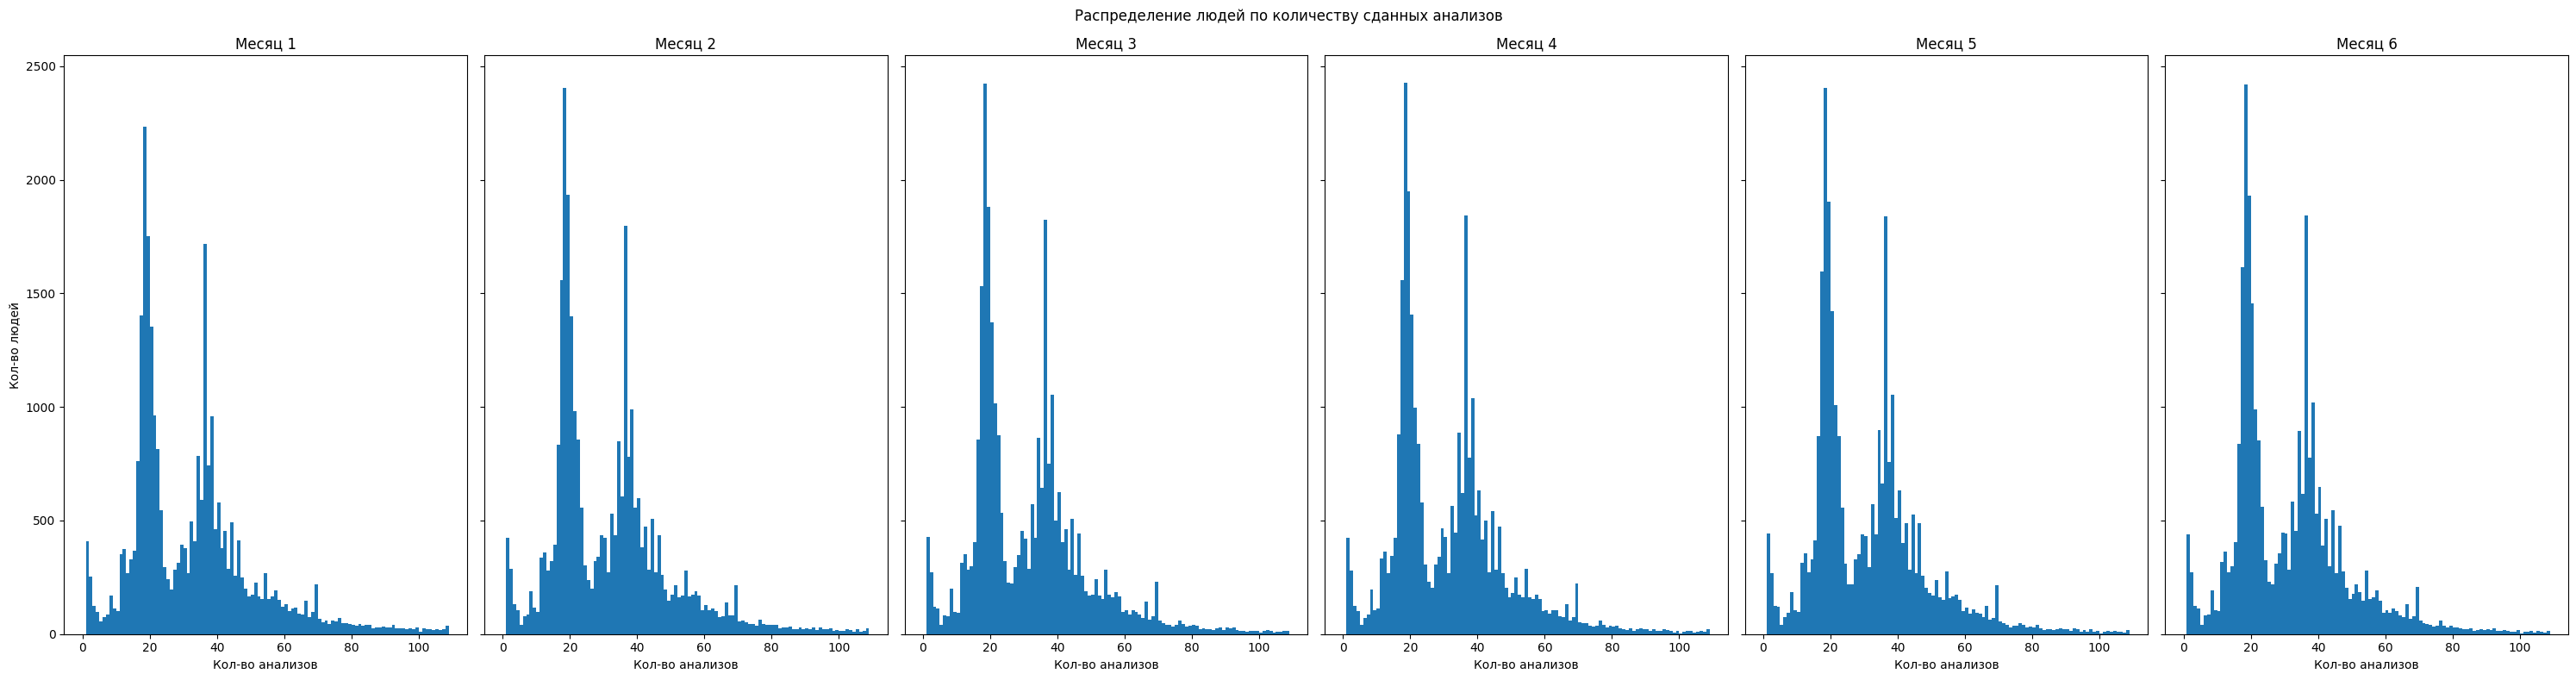

In [8]:
fig, axes = plt.subplots(1, 6, figsize=(30, 8), sharex=True, sharey=True)

for month in range(1, 7):
    count_cols = [col for col in monthes[month].columns if col.endswith('_count_all')]

    num_tests_taken = (monthes[month][count_cols]).sum(axis=1).astype('int')

    axes[month - 1].hist(num_tests_taken, bins=range(0, 110))
    axes[month - 1].set_title(f'Месяц {month}')
    axes[month - 1].set_xlabel('Кол-во анализов')

axes[0].set_ylabel('Кол-во людей')
fig.suptitle('Распределение людей по количеству сданных анализов')
plt.tight_layout()

Построение дефолтной модели XGBoost и Logreg

In [56]:
X_train, y_train, X_test, y_test, _, _ = get_train_test_by_month(month_gap=4, seed=42, dataset_func=create_dataset_offset)

инициализирован датасет с gap=4, сэмплов=31088 (всё)


In [ ]:
xgboost_default = XGBClassifier(
    objective='binary:logistic',
    eval_metric='error',
    n_jobs=-1,
)

xgboost_default.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [63]:
print('XGBoost')
print(accuracy_score(y_true=y_test, y_pred=xgboost_default.predict(X_test)))
print(f1_score(y_true=y_test, y_pred=xgboost_default.predict(X_test)))

XGBoost
0.8105500160823416
0.7579120427455815


In [ ]:
logreg_default = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, n_jobs=-1)),
])

logreg_default.fit(X_train, y_train)

/Users/kirillgorunov/miniconda3/envs/nlp/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

In [66]:
print('Logreg')
print(accuracy_score(y_true=y_test, y_pred=logreg_default.predict(X_test)))
print(f1_score(y_true=y_test, y_pred=logreg_default.predict(X_test)))

Logreg
0.7798327436474751
0.7079155109878387


Переходим к моделям

------
## XGBoost

In [ ]:
def train_xgboost(diag=None):
    results_xgboost = {}
    for month in range(1, 7):
        results_xgboost[month] = {}
        for random_seed in [3, 5, 42]:
            X_train, y_train, X_test, y_test, X_val, y_val = get_train_test_by_month(month_gap=month, seed=random_seed, dataset_func=create_dataset_offset, diag=diag)
            print(f'x train size: {len(X_train)}, x test size: {len(X_test)}')
        
            neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

            print(f'начинаем выбор признаков для модели month={month}. seed = {random_seed}')

            rfecv = RFECV(estimator=XGBClassifier(
                scale_pos_weight=neg / pos,
                objective='binary:logistic',
                n_jobs=1),
                n_jobs=-1,
                step=0.1, # на каждой итерации удаляем 10% признаков
                cv=3, #фолды внутри выбора лучшего признака
                scoring='accuracy'
            )
            rfecv.fit(X_val, y_val)

            selected = X_train.columns[rfecv.support_]

            print(f'выбрано {len(selected)} фичей. приступаем к обучению. seed = {random_seed}')


            X_train = X_train[selected]
            X_test = X_test[selected]
            X_val = X_val[selected]

            def objective(trial):
                params = {
                    'max_depth': trial.suggest_int('max_depth', 3, 7),
                    'learning_rate': trial.suggest_float('learning_rate', 1e-2, 1e-1, log=True),
                    'min_child_weight': trial.suggest_float('min_child_weight', 1, 30, log=True),
                    'reg_alpha': trial.suggest_float('reg_alpha', 1e-2, 10, log=True),
                    'reg_lambda': trial.suggest_float('reg_lambda', 1e-1, 30, log=True),
                    'gamma': trial.suggest_float('gamma', 0, 5),
                    'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                }
                model = XGBClassifier(
                    **params,
                    scale_pos_weight=neg / pos,
                    objective='binary:logistic',
                    eval_metric='error',
                    tree_method='hist',
                    random_state=42,
                    n_jobs=-1,
                    early_stopping_rounds=50,
                    n_estimators=1500,
                    callbacks=[
                        XGBoostPruningCallback(trial, 'validation_0-error')
                    ],
                )

                model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
                preds = model.predict(X_val)
                return accuracy_score(y_val, preds)

            
            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(seed=42),
                pruner=optuna.pruners.MedianPruner(n_warmup_steps=20),
            )
            study.optimize(objective, n_trials=80) #  n_jobs=2

            best_params = study.best_params

            best_model = XGBClassifier(
                **best_params,
                scale_pos_weight=neg / pos,
                objective='binary:logistic',
                eval_metric='error',
                tree_method='hist',
                random_state=42,
                n_estimators=1500,
                early_stopping_rounds=50,
                n_jobs=-1,
            )
            best_model.fit(X_train, y_train, eval_set=[(X_val, y_val)])

            test_pred = best_model.predict(X_test)
            test_proba = best_model.predict_proba(X_test)[:, 1]
            val_pred = best_model.predict(X_val)
            val_proba = best_model.predict_proba(X_val)[:, 1]

            results_xgboost[month][random_seed] = {
                'selected_features': selected.tolist(),
                'n_features': len(selected),
                'best_params': study.best_params,
                'best_score': study.best_value,
                'model': best_model,
                'test_accuracy': accuracy_score(y_test, test_pred),
                'test_f1': f1_score(y_test, test_pred),
                'test_roc_auc': roc_auc_score(y_test, test_proba),
                'val_accuracy': accuracy_score(y_val, val_pred),
                'val_f1': f1_score(y_val, val_pred),
                'val_roc_auc': roc_auc_score(y_val, val_proba),
            }

            print(f"обучена модель на month={month}. seed = {random_seed}. Лучший скор (cv): {study.best_value}. Лучший скор test: {results_xgboost[month][random_seed]['test_accuracy']}")
    return results_xgboost
results_xgboost = train_xgboost()

## CatBoost

In [ ]:
def train_catboost(diag=None):
    results_catboost = {}
    for month in range(1, 7):
        results_catboost[month] = {}
        for random_seed in [3, 5, 42]:
            X_train, y_train, X_test, y_test, X_val, y_val = get_train_test_by_month(month_gap=month, seed=random_seed, dataset_func=create_dataset_offset, diag=diag)

            neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

            print(f'начинаем выбор признаков для модели month={month}. seed = {random_seed}')

            rfecv = RFECV(estimator=CatBoostClassifier(
                scale_pos_weight=neg / pos,
                random_state=42,
                loss_function='Logloss',
                thread_count=-1,
                verbose=False
                ),
                n_jobs=-1,
                step=0.1, # на каждой итерации удаляем 10% признаков
                cv=3, #фолды внутри выбора лучшего признака
                scoring='accuracy'
            )
            rfecv.fit(X_train, y_train)

            selected = X_train.columns[rfecv.support_]

            print(f'выбрано {len(selected)} фичей. приступаем к обучению. seed = {random_seed}')


            X_train = X_train[selected]
            X_test = X_test[selected]
            X_val = X_val[selected]

            def objective(trial):
                params = {
                    'depth': trial.suggest_int('depth', 3, 7),
                    'learning_rate': trial.suggest_float('learning_rate', 1e-2, 1e-1, log=True),
                    'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-1, 30, log=True),
                    'random_strength': trial.suggest_float('random_strength', 1e-2, 10, log=True),
                    'border_count': trial.suggest_categorical('border_count', [32, 64, 128, 254]),
                    'rsm': trial.suggest_float('rsm', 0.6, 1.0),
                    'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
                }
                model = CatBoostClassifier(
                    **params,
                    iterations=1500,
                    scale_pos_weight=neg / pos,
                    loss_function='Logloss',
                    eval_metric='Accuracy',
                    random_state=42,
                    thread_count=-1,
                    verbose=False,
                    early_stopping_rounds=50,
                )

                pruning_cb = CatBoostPruningCallback(trial, 'Accuracy')

                model.fit(
                    X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    callbacks=[pruning_cb],
                )

                pruning_cb.check_pruned()

                return model.best_score_['validation']['Accuracy']

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(seed=42),
                pruner=optuna.pruners.MedianPruner(n_warmup_steps=20),
            )
            study.optimize(objective, n_trials=80)

            best_params = study.best_params

            best_model = CatBoostClassifier(
                **best_params,
                iterations=1500,
                scale_pos_weight=neg / pos,
                loss_function='Logloss',
                eval_metric='Accuracy',
                random_state=42,
                thread_count=-1,
                verbose=False,
                early_stopping_rounds=50,
            )
            best_model.fit(X_train, y_train, eval_set=[(X_val, y_val)])

            test_pred = best_model.predict(X_test)
            test_proba = best_model.predict_proba(X_test)[:, 1]
            val_pred = best_model.predict(X_val)
            val_proba = best_model.predict_proba(X_val)[:, 1]

            results_catboost[month][random_seed] = {
                'selected_features': selected.tolist(),
                'n_features': len(selected),
                'best_params': study.best_params,
                'best_score': study.best_value,
                'model': best_model,
                'test_accuracy': accuracy_score(y_test, test_pred),
                'test_f1': f1_score(y_test, test_pred),
                'test_roc_auc': roc_auc_score(y_test, test_proba),
                'val_accuracy': accuracy_score(y_val, val_pred),
                'val_f1': f1_score(y_val, val_pred),
                'val_roc_auc': roc_auc_score(y_val, val_proba),
            }

            print(f"обучена модель на month={month}. seed = {random_seed}. Лучший скор: {study.best_value}. Лучший скор test: {results_catboost[month][random_seed]['test_accuracy']}")
    return results_catboost
results_catboost = train_catboost()

## Логистическая регрессия

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed

def _fit_logreg_one(month, random_seed, diag=None):
    X_train, y_train, X_test, y_test, X_val, y_val = get_train_test_by_month(
        month_gap=month, seed=random_seed,
        dataset_func=create_dataset_offset, diag=diag
    )

    cols = X_train.columns
    imputer = SimpleImputer(strategy='median', keep_empty_features=True)
    scaler = StandardScaler()

    X_train = pd.DataFrame(
        scaler.fit_transform(imputer.fit_transform(X_train)),
        columns=cols, index=X_train.index,
    )
    X_val = pd.DataFrame(
        scaler.transform(imputer.transform(X_val)),
        columns=cols, index=X_val.index,
    )
    X_test = pd.DataFrame(
        scaler.transform(imputer.transform(X_test)),
        columns=cols, index=X_test.index,
    )

    print(f'начинаем выбор признаков для модели month={month}. seed = {random_seed}')

    rfecv = RFECV(
        estimator=LogisticRegression(
            l1_ratio=0.0,
            class_weight='balanced',
            solver='saga',
            max_iter=2000,
            random_state=42,
        ),
        n_jobs=1,
        step=0.1,
        cv=3,
        scoring='accuracy',
    )
    rfecv.fit(X_train, y_train)

    selected = X_train.columns[rfecv.support_]
    print(f'выбрано {len(selected)} фичей. приступаем к обучению. seed = {random_seed}')

    X_train = X_train[selected]
    X_test = X_test[selected]
    X_val = X_val[selected]

    def objective(trial):
        params = {
            'C': trial.suggest_float('C', 1e-3, 1e2, log=True),
            'l1_ratio': trial.suggest_float('l1_ratio', 0.0, 1.0),
        }
        model = LogisticRegression(
            **params,
            solver='saga',
            class_weight='balanced',
            max_iter=5000,
            random_state=42,
            n_jobs=1,
        )
        model.fit(X_train, y_train)
        return accuracy_score(y_val, model.predict(X_val))

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=20),
    )
    study.optimize(objective, n_trials=80, n_jobs=1)

    best_params = study.best_params

    best_model = LogisticRegression(
        **best_params,
        solver='saga',
        class_weight='balanced',
        max_iter=5000,
        random_state=42,
        n_jobs=1,
    )
    best_model.fit(X_train, y_train)

    test_pred = best_model.predict(X_test)
    test_proba = best_model.predict_proba(X_test)[:, 1]
    val_pred = best_model.predict(X_val)
    val_proba = best_model.predict_proba(X_val)[:, 1]

    result = {
        'selected_features': selected.tolist(),
        'n_features': len(selected),
        'best_params': study.best_params,
        'best_score': study.best_value,
        'model': best_model,
        'test_accuracy': accuracy_score(y_test, test_pred),
        'test_f1': f1_score(y_test, test_pred),
        'test_roc_auc': roc_auc_score(y_test, test_proba),
        'val_accuracy': accuracy_score(y_val, val_pred),
        'val_f1': f1_score(y_val, val_pred),
        'val_roc_auc': roc_auc_score(y_val, val_proba),
    }

    print(f"обучена модель на month={month}. seed = {random_seed}")
    print(f"Лучший скор: {study.best_value}. Лучший скор test: {result['test_accuracy']}")
    return month, random_seed, result

def train_logreg(diag=None, n_jobs=-1):
    tasks = [(month, seed) for month in range(1, 7) for seed in [3, 5, 42]]

    out = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(_fit_logreg_one)(month, seed, diag)
        for month, seed in tasks
    )

    results_logreg = {month: {} for month in range(1, 7)}
    for month, seed, result in out:
        results_logreg[month][seed] = result
    return results_logreg

results_logreg = train_logreg()

## Adaboost

In [ ]:
results_adaboost = {}

for month in range(1, 7):
    results_adaboost[month] = {}
    for random_seed in [3, 5, 42]:
        X_train, y_train, X_test, y_test, X_val, y_val = get_train_test_by_month(month_gap=month, seed=random_seed, dataset_func=create_dataset_offset)

        print('заполняем медианой пропуски (adaboost требует)')
        imputer = SimpleImputer(strategy="median")

        X_train_imp = pd.DataFrame(
            imputer.fit_transform(X_train),
            columns=X_train.columns,
            index=X_train.index
        )

        X_val_imp = pd.DataFrame(
            imputer.transform(X_val),
            columns=X_val.columns,
            index=X_val.index
        )

        X_test_imp = pd.DataFrame(
            imputer.transform(X_test),
            columns=X_test.columns,
            index=X_test.index
        )

        X_train = X_train_imp
        X_val = X_val_imp
        X_test = X_test_imp

        neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

        print(f'начинаем выбор признаков для модели month={month}. seed = {random_seed}')

        rfecv = RFECV(estimator=AdaBoostClassifier(
            estimator=DecisionTreeClassifier(
                class_weight='balanced',
                max_depth=3,
                random_state=42,
            ),
            random_state=42,
            ),
            n_jobs=-1,
            step=0.1, # на каждой итерации удаляем 10% признаков
            cv=3, #фолды внутри выбора лучшего признака
            scoring='accuracy'
        )
        rfecv.fit(X_val, y_val)

        selected = X_train.columns[rfecv.support_]

        print(f'выбрано {len(selected)} фичей. приступаем к обучению. seed = {random_seed}')


        X_train = X_train[selected]
        X_test = X_test[selected]
        X_val = X_val[selected]

        model = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(
                class_weight='balanced',
                max_depth=3,
                random_state=42,
            ),
            random_state=42
        )

        param_grid = {
            'n_estimators': np.linspace(100, 600, 3, dtype=int).tolist(),
            'learning_rate': np.logspace(-2, 0, 3).tolist(),
            'estimator__max_depth': [1, 2, 3]
        }


        search = RandomizedSearchCV(model, param_grid, n_iter=80, cv=5,
        scoring='accuracy', n_jobs=-1, random_state=42, refit=True)

        sw = compute_sample_weight('balanced', y_train)
        search.fit(X_val, y_val, sample_weight=sw)

        best_model = search.best_estimator_

        test_pred = best_model.predict(X_test)
        test_proba = best_model.predict_proba(X_test)[:, 1]
        val_pred = best_model.predict(X_val)
        val_proba = best_model.predict_proba(X_val)[:, 1]

        results_adaboost[month][random_seed] = {
            'selected_features': selected.tolist(),
            'n_features': len(selected),
            'best_params': search.best_params_,
            'best_score': search.best_score_,
            'model': search.best_estimator_,
            'test_accuracy': accuracy_score(y_test, test_pred),
            'test_f1': f1_score(y_test, test_pred),
            'test_roc_auc': roc_auc_score(y_test, test_proba),
            'val_accuracy': accuracy_score(y_val, val_pred),
            'val_f1': f1_score(y_val, val_pred),
            'val_roc_auc': roc_auc_score(y_val, val_proba),
        }

        print(f"обучена модель на month={month}. seed = {random_seed}. Лучший скор (cv): {search.best_score_}. Лучший скор test: {results_adaboost[month][random_seed]['test_accuracy']}")


## Random forest

In [ ]:
results_rf = {}
for month in range(1, 7):
    results_rf[month] = {}
    for random_seed in [3, 5, 42]:
        X_train, y_train, X_test, y_test, X_val, y_val = get_train_test_by_month(month_gap=month, seed=random_seed, dataset_func=create_dataset_offset)

        print('заполняем медианой пропуски (rf требует)')
        imputer = SimpleImputer(strategy="median")

        X_train_imp = pd.DataFrame(
            imputer.fit_transform(X_train),
            columns=X_train.columns,
            index=X_train.index
        )

        X_val_imp = pd.DataFrame(
            imputer.transform(X_val),
            columns=X_val.columns,
            index=X_val.index
        )

        X_test_imp = pd.DataFrame(
            imputer.transform(X_test),
            columns=X_test.columns,
            index=X_test.index
        )

        X_train = X_train_imp
        X_val = X_val_imp
        X_test = X_test_imp

        neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

        print(f'начинаем выбор признаков для модели month={month}. seed = {random_seed}')

        rfecv = RFECV(estimator=RandomForestClassifier(
            class_weight='balanced',
            random_state=42,
            n_jobs=1,
            ),
            n_jobs=-1,
            step=0.1, # на каждой итерации удаляем 10% признаков
            cv=3, #фолды внутри выбора лучшего признака
            scoring='accuracy'
        )
        rfecv.fit(X_val, y_val)

        selected = X_train.columns[rfecv.support_]

        print(f'выбрано {len(selected)} фичей. приступаем к обучению. seed = {random_seed}')


        X_train = X_train[selected]
        X_test = X_test[selected]
        X_val = X_val[selected]

        model = RandomForestClassifier(
            class_weight='balanced',
            random_state=42,
            n_jobs=1
        )

        param_grid = {
            'n_estimators': np.linspace(200, 1000, 3, dtype=int).tolist(),
            'max_depth': [None, 5, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 5],
            'max_features': ['sqrt', 'log2', 0.5],
            'bootstrap': [True, False]
        }


        search = RandomizedSearchCV(model, param_grid, n_iter=80, cv=5,
        scoring='accuracy', n_jobs=-1, random_state=42, refit=True)

        search.fit(X_val, y_val)

        best_model = search.best_estimator_

        test_pred = best_model.predict(X_test)
        test_proba = best_model.predict_proba(X_test)[:, 1]
        val_pred = best_model.predict(X_val)
        val_proba = best_model.predict_proba(X_val)[:, 1]

        results_rf[month][random_seed] = {
            'selected_features': selected.tolist(),
            'n_features': len(selected),
            'best_params': search.best_params_,
            'best_score': search.best_score_,
            'model': search.best_estimator_,
            'test_accuracy': accuracy_score(y_test, test_pred),
            'test_f1': f1_score(y_test, test_pred),
            'test_roc_auc': roc_auc_score(y_test, test_proba),
            'val_accuracy': accuracy_score(y_val, val_pred),
            'val_f1': f1_score(y_val, val_pred),
            'val_roc_auc': roc_auc_score(y_val, val_proba)
        }

        print(f"обучена модель на month={month}. seed = {random_seed}. Лучший скор (cv): {search.best_score_}. Лучший скор test: {results_rf[month][random_seed]['test_accuracy']}")


Отображение результатов первых экспериментов:

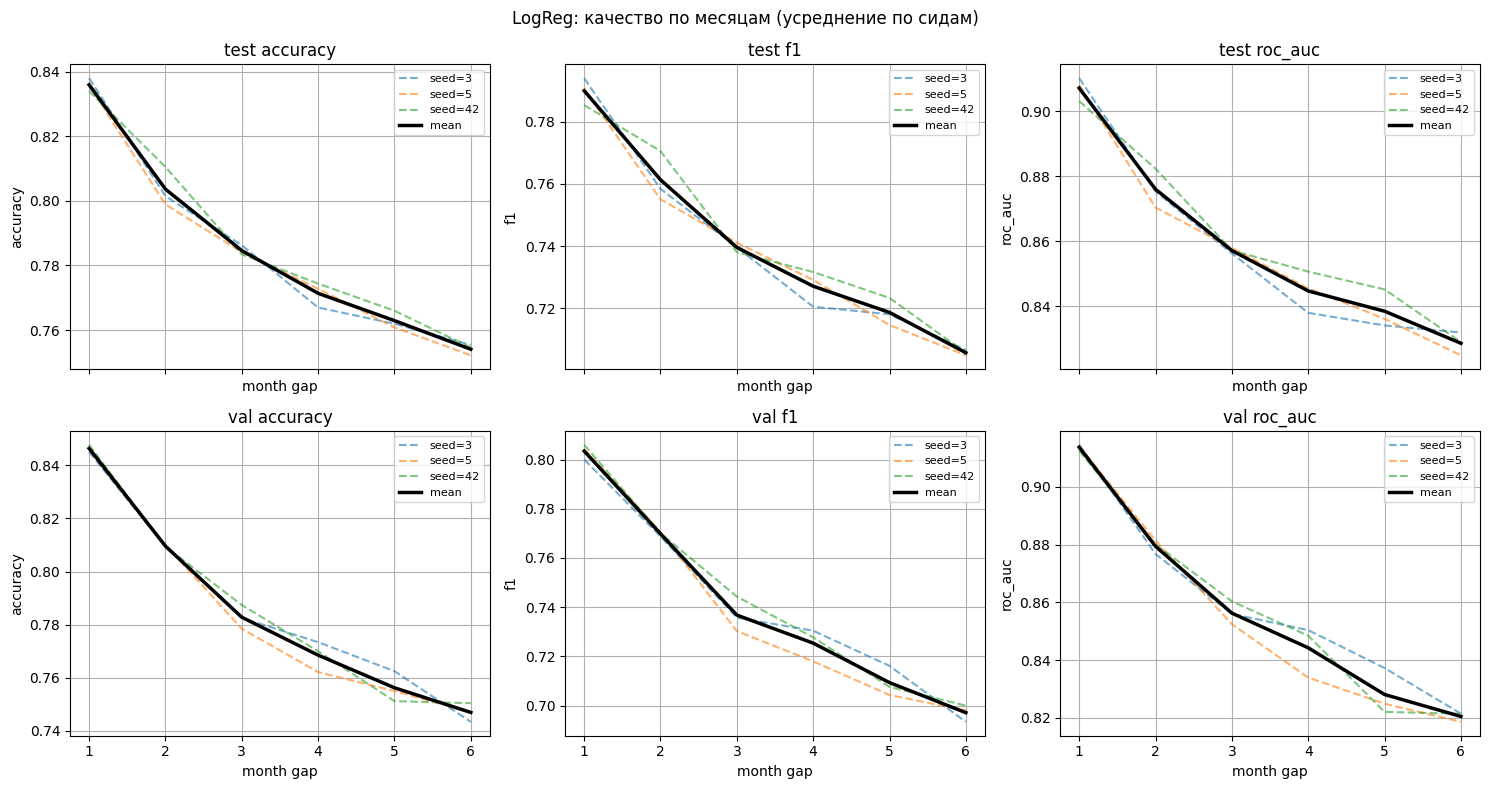

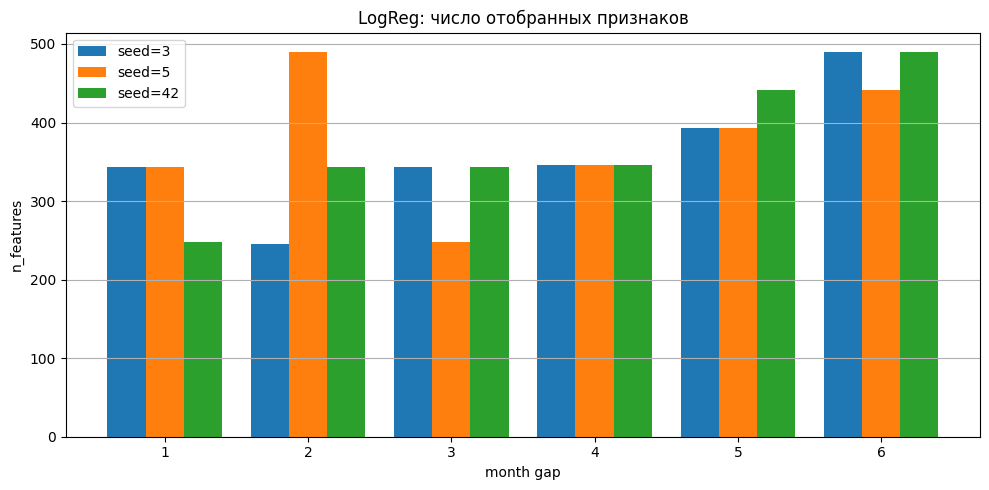

In [ ]:
def plot_results(results, model_name='model'):
    months = list(range(1, 7))
    seeds  = sorted(next(iter(results.values())).keys())
    metrics = ['accuracy', 'f1', 'roc_auc']
    splits  = ['test', 'val']

    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
    for i, split in enumerate(splits):
        for j, metric in enumerate(metrics):
            ax = axes[i, j]
            key = f'{split}_{metric}'

            mat = np.array([[results[m][s][key] for m in months] for s in seeds])

            for s_idx, s in enumerate(seeds):
                ax.plot(months, mat[s_idx], linestyle='--', alpha=0.6, label=f'seed={s}')

            ax.plot(months, mat.mean(axis=0), linewidth=2.5, color='black', label='mean')

            ax.set_title(f'{split} {metric}')
            ax.set_xlabel('month gap')
            ax.set_ylabel(metric)
            ax.grid(True)
            ax.legend(fontsize=8)

    plt.suptitle(f'{model_name}: качество по месяцам (усреднение по сидам)')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    width = 0.8 / len(seeds)
    x = np.arange(len(months))

    for s_idx, s in enumerate(seeds):
        n_feats = [results[m][s]['n_features'] for m in months]
        ax.bar(x + s_idx * width, n_feats, width, label=f'seed={s}')

    ax.set_xticks(x + width * (len(seeds) - 1) / 2)
    ax.set_xticklabels(months)
    ax.set_xlabel('month gap')
    ax.set_ylabel('n_features')
    ax.set_title(f'{model_name}: число отобранных признаков')
    ax.grid(True, axis='y')
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_results(results_xgboost, 'XGBoost')
plot_results(results_catboost, 'CatBoost')
plot_results(results_adaboost, 'AdaBoost')
plot_results(results_rf, 'RandomForest')
plot_results(results_logreg, 'LogReg')

отдельный подсчет числа выбранных признаков для моделей

In [ ]:
from collections import Counter

def top_frequent_features(results, top_n=30, model_name='model'):
    counter = Counter()
    total = 0
    for month, by_seed in results.items():
        for seed, res in by_seed.items():
            counter.update(res['selected_features'])
            total += 1

    for feat, cnt in counter.most_common(top_n):
        print(f'{cnt:>3} / {total}   {feat}')

    in_all = [f for f, c in counter.items() if c == total]
    print(f'в {total} запусках отобрано{len(in_all)} признаков')
    for f in in_all:
        print(f)


top_frequent_features(results_xgboost, model_name='XGBoost')
top_frequent_features(results_catboost, model_name='CatBoost')
top_frequent_features(results_adaboost, model_name='AdaBoost')
top_frequent_features(results_rf, model_name='RandomForest')
top_frequent_features(results_logreg, model_name='LogReg')

На этом этапе большинство моделей и их настроек были сохранены в формат .pkl

дальнейшая часть подгружает готовые данные из .pkl

In [ ]:
with open('results_xgboost.pkl','rb') as f:
    xgb = pickle.load(f)

with open('results_catboost.pkl','rb') as f:
    cat = pickle.load(f)

with open('results_xgboost_optuna.pkl','rb') as f:
    xgb_optuna = pickle.load(f)

with open('results_catboost_optuna.pkl','rb') as f:
    cat_optuna = pickle.load(f)

with open('results_logreg.pkl','rb') as f:
    logreg = pickle.load(f)

Формула для метрики стабильности из работы

In [ ]:
def metric_stability(predictions, y_test=None):

    def S(predictions_, d=0.0):
        diff = predictions_ - 0.5
        sign = np.sign(diff)
        indicator = (np.abs(diff) > d).astype(float)
        return sign * indicator

    def M(predictions_, d=0.0):
        s = S(predictions_, d)
        s_bar = s.mean(axis=0)
        return (1 - np.abs(s_bar)).mean()

    ds = np.linspace(0, 0.5, 50)
    ms = [M(predictions, d) for d in ds]
    area = np.trapezoid(ms, ds)

    area_normalized = area / (ds[-1] - ds[0])
    return area_normalized

Отдельная модель, максимизирующая стабильность

In [ ]:
def train_xgboost(diag=None):
    results_xgboost = {}
    for month in range(1, 7):
        results_xgboost[month] = {}
        for random_seed in [3, 5, 42]:
            X_train, y_train, X_test, y_test, X_val, y_val = get_train_test_by_month(month_gap=month, seed=random_seed, dataset_func=create_dataset_offset, diag=diag)
            print(f'x train size: {len(X_train)}, x test size: {len(X_test)}')

            neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

            print(f'начинаем выбор признаков для модели month={month}. seed = {random_seed}')

            rfecv = RFECV(estimator=XGBClassifier(
                scale_pos_weight=neg / pos,
                objective='binary:logistic',
                n_jobs=1),
                n_jobs=-1,
                step=0.1,
                cv=3,
                scoring='accuracy'
            )
            rfecv.fit(X_val, y_val)

            selected = X_train.columns[rfecv.support_]

            print(f'выбрано {len(selected)} фичей. приступаем к обучению. seed = {random_seed}')

            X_train = X_train[selected]
            X_test = X_test[selected]
            X_val = X_val[selected]

            def objective(trial):
                params = {
                    'max_depth': trial.suggest_int('max_depth', 3, 7),
                    'learning_rate': trial.suggest_float('learning_rate', 1e-2, 1e-1, log=True),
                    'min_child_weight': trial.suggest_float('min_child_weight', 1, 30, log=True),
                    'reg_alpha': trial.suggest_float('reg_alpha', 1e-2, 10, log=True),
                    'reg_lambda': trial.suggest_float('reg_lambda', 1e-1, 30, log=True),
                    'gamma': trial.suggest_float('gamma', 0, 5),
                    'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                }
                runs = []
                for seed in range(1, 20):
                    model = XGBClassifier(
                        **params,
                        scale_pos_weight=neg / pos,
                        objective='binary:logistic',
                        eval_metric='error',
                        tree_method='hist',
                        random_state=seed,
                        n_jobs=-1,
                        early_stopping_rounds=50,
                        n_estimators=1500,
                    )
                    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
                    runs.append(model.predict_proba(X_val)[:, 1])
                return metric_stability(np.vstack(runs))

            study = optuna.create_study(
                direction='minimize',
                sampler=optuna.samplers.TPESampler(seed=42),
            )
            study.optimize(objective, n_trials=80)

            best_params = study.best_params

            best_model = XGBClassifier(
                **best_params,
                scale_pos_weight=neg / pos,
                objective='binary:logistic',
                eval_metric='error',
                tree_method='hist',
                random_state=42,
                n_estimators=1500,
                early_stopping_rounds=50,
                n_jobs=-1,
            )
            best_model.fit(X_train, y_train, eval_set=[(X_val, y_val)])

            test_pred = best_model.predict(X_test)
            test_proba = best_model.predict_proba(X_test)[:, 1]
            val_pred = best_model.predict(X_val)
            val_proba = best_model.predict_proba(X_val)[:, 1]

            results_xgboost[month][random_seed] = {
                'selected_features': selected.tolist(),
                'n_features': len(selected),
                'best_params': study.best_params,
                'best_stability': study.best_value,
                'model': best_model,
                'test_accuracy': accuracy_score(y_test, test_pred),
                'test_f1': f1_score(y_test, test_pred),
                'test_roc_auc': roc_auc_score(y_test, test_proba),
                'val_accuracy': accuracy_score(y_val, val_pred),
                'val_f1': f1_score(y_val, val_pred),
                'val_roc_auc': roc_auc_score(y_val, val_proba),
            }

            print(f"обучена модель на month={month}. seed = {random_seed}. Лучшая стабильность: {study.best_value}. test acc: {results_xgboost[month][random_seed]['test_accuracy']}")
    return results_xgboost
results_xgboost_stability = train_xgboost()

Подсчет стабильности на моделях

In [208]:
X_train, y_train, X_test, y_test, X_val, y_val = get_train_test_by_month(month_gap=month, seed=42, dataset_func=create_dataset_offset)

инициализирован датасет с gap=1, сэмплов=30212 (всё)


In [ ]:
stability = {}
for month in [1,2,3,4,5,6]:
    X_train, y_train, X_test, y_test, X_val, y_val = get_train_test_by_month(month_gap=month, seed=42, dataset_func=create_dataset_offset)

    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    stability[month] = {}

    preds_for_seed = {}
    for state_seed in [3, 5, 42]:
        print('обучаю сид:', state_seed)
        selected = results_logreg[month][state_seed]['selected_features']
        best_params = results_logreg[month][state_seed]['best_params']

        X_tr = X_train[selected]
        X_va = X_val[selected]
        X_te = X_test[selected]

        runs = []
        for seed in range(1, 21):
            print('ok', seed)
            model = XGBClassifier(
                **best_params,
                scale_pos_weight=neg / pos,
                objective='binary:logistic',
                eval_metric='error',
                tree_method='hist',
                random_state=seed,
                n_jobs=-1,
            )

            model.fit(X_tr, y_train, eval_set=[(X_va, y_val)], verbose=False)
            runs.append(model.predict_proba(X_te)[:, 1])

        preds_for_seed[state_seed] = np.vstack(runs)
        stability[month][state_seed] = metric_stability(preds_for_seed[state_seed]) 

Для логрег многопоточный вариант

In [ ]:
def stability_one(month, state_seed):
    X_train, y_train, X_test, y_test, X_val, y_val = get_train_test_by_month(
        month_gap=month, seed=42, dataset_func=create_dataset_offset
    )

    selected = results_logreg[month][state_seed]['selected_features']
    best_params = results_logreg[month][state_seed]['best_params']

    cols = X_train.columns
    imputer = SimpleImputer(strategy='median', keep_empty_features=True)
    scaler = StandardScaler()
    X_tr_full = pd.DataFrame(
        scaler.fit_transform(imputer.fit_transform(X_train)),
        columns=cols, index=X_train.index,
    )
    X_te_full = pd.DataFrame(
        scaler.transform(imputer.transform(X_test)),
        columns=cols, index=X_test.index,
    )

    X_tr = X_tr_full[selected]
    X_te = X_te_full[selected]

    runs = []
    for seed in range(1, 21):
        model = LogisticRegression(
            **best_params,
            solver='saga',
            class_weight='balanced',
            max_iter=5000,
            random_state=seed,
        )
        model.fit(X_tr, y_train)
        runs.append(model.predict_proba(X_te)[:, 1])

    preds = np.vstack(runs)
    print(f'готово month={month} seed={state_seed}')
    return month, state_seed, metric_stability(preds)


def compute_stability(n_jobs=-1):
    tasks = [(m, s) for m in [1, 2, 3, 4, 5, 6] for s in [3, 5, 42]]
    out = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(stability_one)(m, s) for m, s in tasks
    )
    stability = {m: {} for m in [1, 2, 3, 4, 5, 6]}
    for m, s, val in out:
        stability[m][s] = val
    return stability


stability = compute_stability()

Отображение результатов стабильности

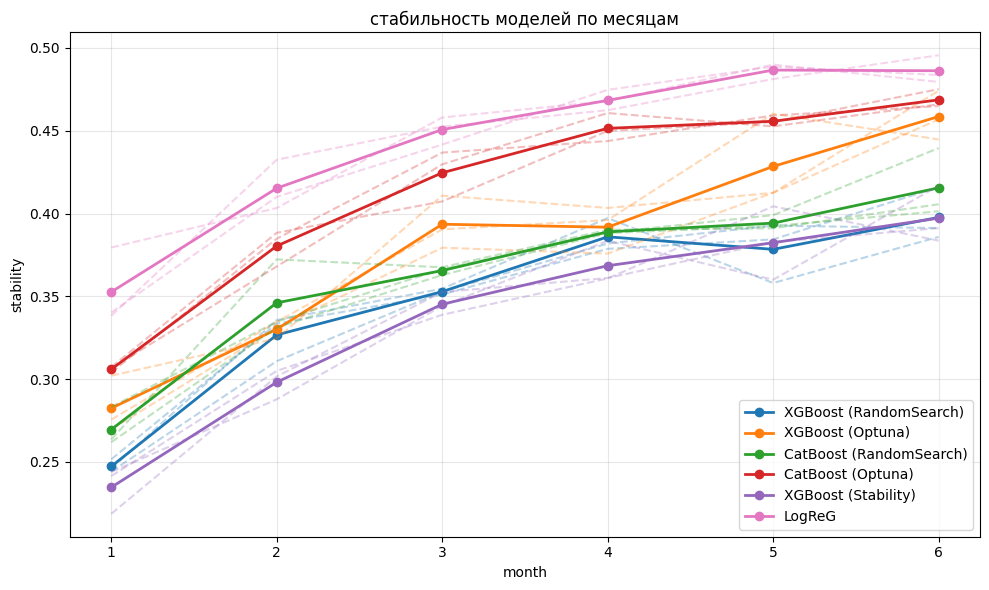

In [ ]:
files = {
    'XGBoost (RandomSearch)': 'stability_xgboost.pkl',
    'XGBoost (Optuna)': 'stability_xgboost_optuna.pkl',
    'CatBoost (RandomSearch)': 'stability_catboost.pkl',
    'CatBoost (Optuna)': 'stability_catboost_optuna.pkl',
    'XGBoost (Stability)': 'results_xgboost_stability.pkl',
    'LogReG': 'stability_logreg.pkl',
}

colors = {
    'XGBoost (RandomSearch)': 'tab:blue',
    'XGBoost (Optuna)':  'tab:orange',
    'CatBoost (RandomSearch)': 'tab:green',
    'CatBoost (Optuna)': 'tab:red',
    'XGBoost (Stability)': 'tab:purple',
    'LogReG': 'tab:pink',
}

plt.figure(figsize=(10, 6))
def stab_val(v):
    return v['best_stability'] if isinstance(v, dict) else v


for name, path in files.items():
    with open(path, 'rb') as f:
        stab = pickle.load(f)

    months = sorted(stab.keys())
    seeds = sorted({s for m in months for s in stab[m].keys()})
    c = colors[name]

    for s in seeds:
        vals = [stab_val(stab[m][s]) for m in months]
        plt.plot(months, vals, linestyle='--', alpha=0.3, color=c)

    mean_vals = [np.mean([stab_val(stab[m][s]) for s in seeds]) for m in months]
    plt.plot(months, mean_vals, color=c, linewidth=2, marker='o', label=name)

plt.xlabel('month')
plt.ylabel('stability')
plt.title('стабильность моделей по месяцам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stability_all.png', dpi=150)
plt.show()


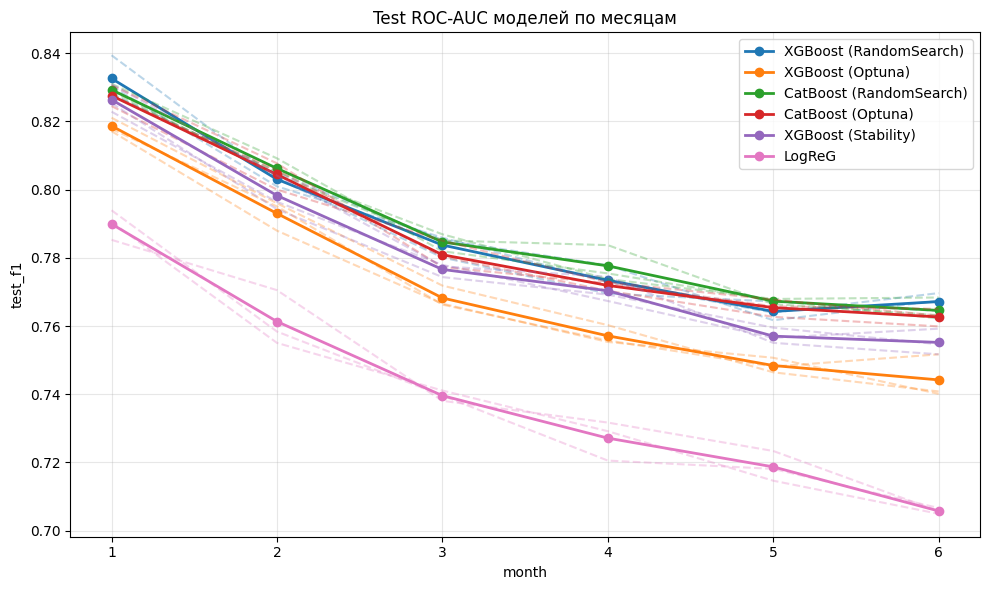

In [ ]:
files = {
    'XGBoost (RandomSearch)': 'results_xgboost.pkl',
    'XGBoost (Optuna)': 'results_xgboost_optuna.pkl',
    'CatBoost (RandomSearch)': 'results_catboost.pkl',
    'CatBoost (Optuna)': 'results_catboost_optuna.pkl',
    'XGBoost (Stability)': 'results_xgboost_stability.pkl',
    'LogReG': 'results_logreg.pkl',
}

colors = {
    'XGBoost (RandomSearch)': 'tab:blue',
    'XGBoost (Optuna)':  'tab:orange',
    'CatBoost (RandomSearch)': 'tab:green',
    'CatBoost (Optuna)': 'tab:red',
    'XGBoost (Stability)': 'tab:purple',
    'LogReG': 'tab:pink',
}

metric = 'test_f1'

plt.figure(figsize=(10, 6))

for name, path in files.items():
    with open(path, 'rb') as f:
        res = pickle.load(f)

    months = sorted(res.keys())
    seeds = sorted({s for m in months for s in res[m].keys()})
    c = colors[name]

    for s in seeds:
        vals = [res[m][s][metric] for m in months]
        plt.plot(months, vals, linestyle='--', alpha=0.3, color=c)

    mean_vals = [np.mean([res[m][s][metric] for s in seeds]) for m in months]
    plt.plot(months, mean_vals, color=c, linewidth=2, marker='o', label=name)

plt.xlabel('month')
plt.ylabel(metric)
plt.title(f'Test {metric} моделей по месяцам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'quality_{metric}.png', dpi=150)

Смешанная метрика по датасету

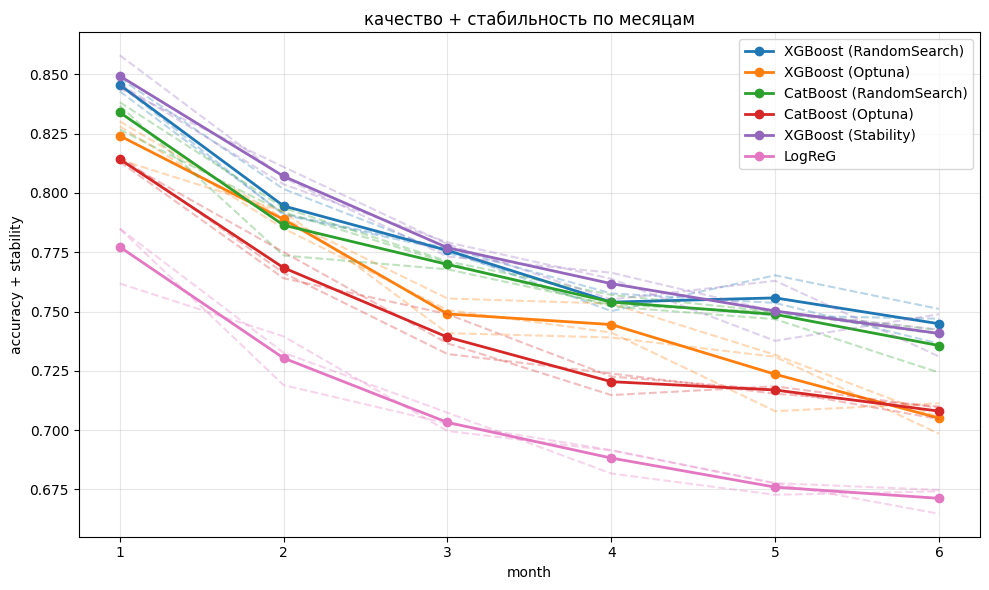

In [ ]:
stability_files = {
    'XGBoost (RandomSearch)': 'stability_xgboost.pkl',
    'XGBoost (Optuna)': 'stability_xgboost_optuna.pkl',
    'CatBoost (RandomSearch)':'stability_catboost.pkl',
    'CatBoost (Optuna)': 'stability_catboost_optuna.pkl',
    'XGBoost (Stability)': 'results_xgboost_stability.pkl',
    'LogReG': 'stability_logreg.pkl'
}
quality_files = {
    'XGBoost (RandomSearch)': 'results_xgboost.pkl',
    'XGBoost (Optuna)': 'results_xgboost_optuna.pkl',
    'CatBoost (RandomSearch)':'results_catboost.pkl',
    'CatBoost (Optuna)': 'results_catboost_optuna.pkl',
    'XGBoost (Stability)': 'results_xgboost_stability.pkl',
    'LogReG': 'results_logreg.pkl'
}
colors = {
    'XGBoost (RandomSearch)': 'tab:blue',
    'XGBoost (Optuna)': 'tab:orange',
    'CatBoost (RandomSearch)':'tab:green',
    'CatBoost (Optuna)': 'tab:red',
    'XGBoost (Stability)': 'tab:purple',
    'LogReG': 'tab:pink'
}

metric = 'test_roc_auc'
alpha = 0.5

def stab_leaf(v):
    return v['best_stability'] if isinstance(v, dict) else float(v)

def qual_leaf(v):
    return v[metric] if isinstance(v, dict) and metric in v else None

def combine(q, instab):
    s = 1.0 - instab
    return alpha * q + (1 - alpha) * s


plt.figure(figsize=(10, 6))
for name in quality_files:
    with open(quality_files[name], 'rb') as f:
        res = pickle.load(f)
    with open(stability_files[name], 'rb') as f:
        stab = pickle.load(f)

    months = sorted(set(res) & set(stab))
    seeds = sorted(set.intersection(
        {s for m in months for s in res[m]},
        {s for m in months for s in stab[m]},
    ))

    if qual_leaf(res[months[0]][seeds[0]]) is None:
        print(f'пропускаю {name}')
        continue

    c = colors[name]
    for s in seeds:
        vals = [combine(qual_leaf(res[m][s]), stab_leaf(stab[m][s])) for m in months]
        plt.plot(months, vals, linestyle='--', alpha=0.3, color=c)

    mean_vals = [np.mean([combine(qual_leaf(res[m][s]), stab_leaf(stab[m][s])) for s in seeds])
                for m in months]
    plt.plot(months, mean_vals, color=c, linewidth=2, marker='o', label=name)

plt.xlabel('month')
plt.ylabel(f'accuracy + stability')
plt.title('качество + стабильность по месяцам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('composite.png', dpi=150)

Дополнительный подсчет стабильности (xgboost + catboost)

In [ ]:
stability={}
for month in [1, 2, 3, 4, 5, 6]:
    X_train, y_train, X_test, y_test, X_val, y_val = get_train_test_by_month(month_gap=month, seed=42, dataset_func=create_dataset_offset)

    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    stability[month] = {}

    preds_for_seed = {}
    for state_seed in [3, 5, 42]:
        print('обучаю сид:', state_seed)
        selected = xgb_optuna[month][state_seed]['selected_features']
        best_params = xgb_optuna[month][state_seed]['best_params']

        X_tr = X_train[selected]
        X_va = X_val[selected]
        X_te = X_test[selected]

        runs = []
        for seed in range(1, 21):
            print('ok', seed)
            model = XGBClassifier(
                **best_params,
                scale_pos_weight=neg / pos,
                objective='binary:logistic',
                eval_metric='error',
                tree_method='hist',
                random_state=seed,
                n_jobs=-1,
                early_stopping_rounds=50,
                n_estimators=1500,
            )
            model.fit(X_tr, y_train, eval_set=[(X_va, y_val)], verbose=False)
            runs.append(model.predict_proba(X_te)[:, 1])

        preds_for_seed[state_seed] = np.vstack(runs)
        stability[month][state_seed] = metric_stability(preds_for_seed[state_seed]) 

In [ ]:
stability={}
for month in [1, 2, 3, 4, 5, 6]:
    X_train, y_train, X_test, y_test, X_val, y_val = get_train_test_by_month(month_gap=month, seed=42, dataset_func=create_dataset_offset)

    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    stability[month] = {}

    preds_for_seed = {}
    for state_seed in [3, 5, 42]:
        print('обучаю сид:', state_seed)
        selected = cat_optuna[month][state_seed]['selected_features']
        best_params = cat_optuna[month][state_seed]['best_params']

        X_tr = X_train[selected]
        X_va = X_val[selected]
        X_te = X_test[selected]

        runs = []
        for seed in range(1, 21):
            print('ok', seed)
            model = CatBoostClassifier(
                **best_params,
                iterations=1500,
                scale_pos_weight=neg / pos,
                loss_function='Logloss',
                eval_metric='Accuracy',
                random_state=seed,
                thread_count=-1,
                early_stopping_rounds=50,
                verbose=False,
            )
            model.fit(X_tr, y_train, eval_set=[(X_va, y_val)])
            runs.append(model.predict_proba(X_te)[:, 1])

        preds_for_seed[state_seed] = np.vstack(runs)
        stability[month][state_seed] = metric_stability(preds_for_seed[state_seed])

# Модели на отдельных диагнозах (локальные)

In [19]:
diag_cat = (
    diagnoses['diag_code'].dropna().astype(str)
    .loc[lambda s: s.str.startswith('C')]
    .str.split('.').str[0]
)

all_diag = sorted(diag_cat.unique())

In [20]:
diag_massive = (
    diagnoses
    .assign(diag_cat=diagnoses['diag_code'].astype(str).str.split('.').str[0])
    .loc[lambda d: d['diag_cat'].str.startswith('C')]
    .groupby('diag_cat')['patient_id'].nunique()
    .sort_values(ascending=False)
    .to_dict()
)


In [21]:
diag_table = [k for k, v in diag_massive.items() if v > 1000]
diag_table

['C50', 'C18', 'C34', 'C16', 'C20', 'C61', 'C56', 'C25']

Отдельно CatBoost и XGBoost

In [ ]:
xgboost_via_diag = dict()
for diag in diag_table:
    xgboost_via_diag[diag] = train_xgboost(diag)

In [ ]:
catboost_via_diag = dict()
for diag in diag_table:
    catboost_via_diag[diag] = train_catboost(diag)

In [ ]:
stability_via_diag = {}

for diag in diag_table:
    xgb_m = xgboost_via_diag[diag]
    stability_via_diag[diag] = {}
    for month in xgb_m:
        X_train, y_train, X_test, y_test, X_val, y_val = get_train_test_by_month(
            month_gap=month, seed=42, dataset_func=create_dataset_offset, diag=diag)
        neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
        stability_via_diag[diag][month] = {}
        for state_seed in xgb_m[month]:
            selected = xgb_m[month][state_seed]['selected_features']
            best_params = xgb_m[month][state_seed]['best_params']
            X_tr, X_va, X_te = X_train[selected], X_val[selected], X_test[selected]

            runs = []
            for seed in range(1, 21):
                model = XGBClassifier(
                    **best_params,
                    scale_pos_weight=neg / pos,
                    objective='binary:logistic',
                    eval_metric='error',
                    tree_method='hist',
                    random_state=seed,
                    n_jobs=-1,
                    early_stopping_rounds=50,
                    n_estimators=1500,
                )
                model.fit(X_tr, y_train, eval_set=[(X_va, y_val)], verbose=False)
                runs.append(model.predict_proba(X_te)[:, 1])

            stability_via_diag[diag][month][state_seed] = metric_stability(np.vstack(runs))

In [ ]:
stability_via_diag_cat = {}

for diag in diag_table:
    cat = catboost_via_diag[diag]
    stability_via_diag_cat[diag] = {}
    for month in cat:
        X_train, y_train, X_test, y_test, X_val, y_val = get_train_test_by_month(
            month_gap=month, seed=42, dataset_func=create_dataset_offset, diag=diag)
        neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
        stability_via_diag_cat[diag][month] = {}
        for state_seed in cat[month]:
            selected = cat[month][state_seed]['selected_features']
            best_params = cat[month][state_seed]['best_params']
            X_tr, X_va, X_te = X_train[selected], X_val[selected], X_test[selected]

            runs = []
            for seed in range(1, 21):
                model = CatBoostClassifier(
                    **best_params,
                    iterations=1500,
                    scale_pos_weight=neg / pos,
                    loss_function='Logloss',
                    eval_metric='Accuracy',
                    random_state=seed,
                    thread_count=-1,
                    early_stopping_rounds=50,
                    verbose=False,
                )
                model.fit(X_tr, y_train, eval_set=[(X_va, y_val)])
                runs.append(model.predict_proba(X_te)[:, 1])

            stability_via_diag_cat[diag][month][state_seed] = metric_stability(np.vstack(runs))

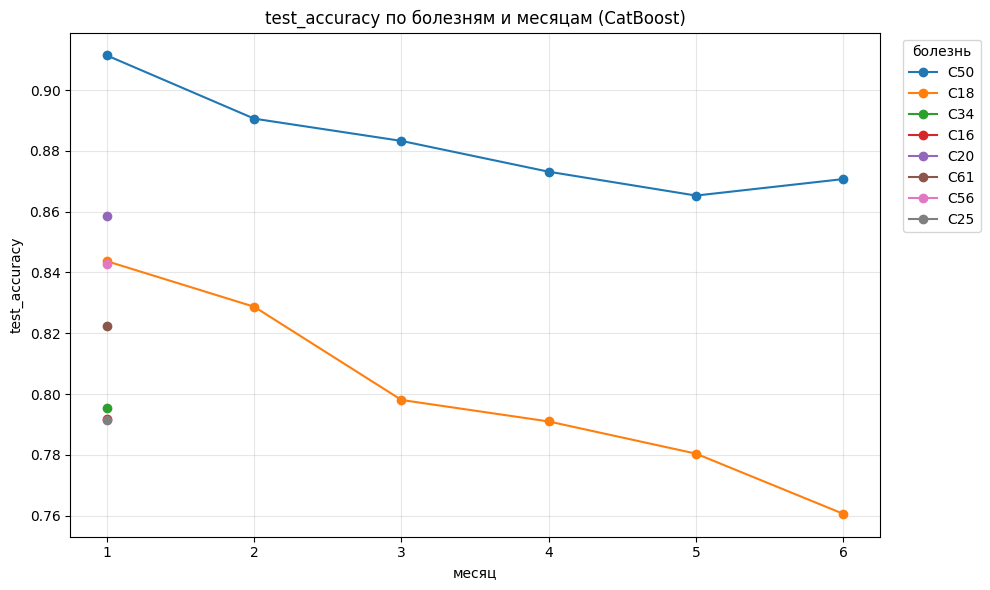

In [ ]:
plt.figure(figsize=(10, 6))

for diag, res in xgboost_via_diag.items():
    months = sorted(res.keys())
    mean_vals = [np.mean([res[m][s]['test_accuracy'] for s in res[m]]) for m in months]
    plt.plot(months, mean_vals, marker='o', label=str(diag))

plt.xlabel('месяц')
plt.ylabel('test_accuracy')
plt.title(f'test_accuracy по болезням и месяцам (CatBoost)')
plt.legend(title='болезнь', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.savefig('xgboost_via_diag.png', dpi=150)

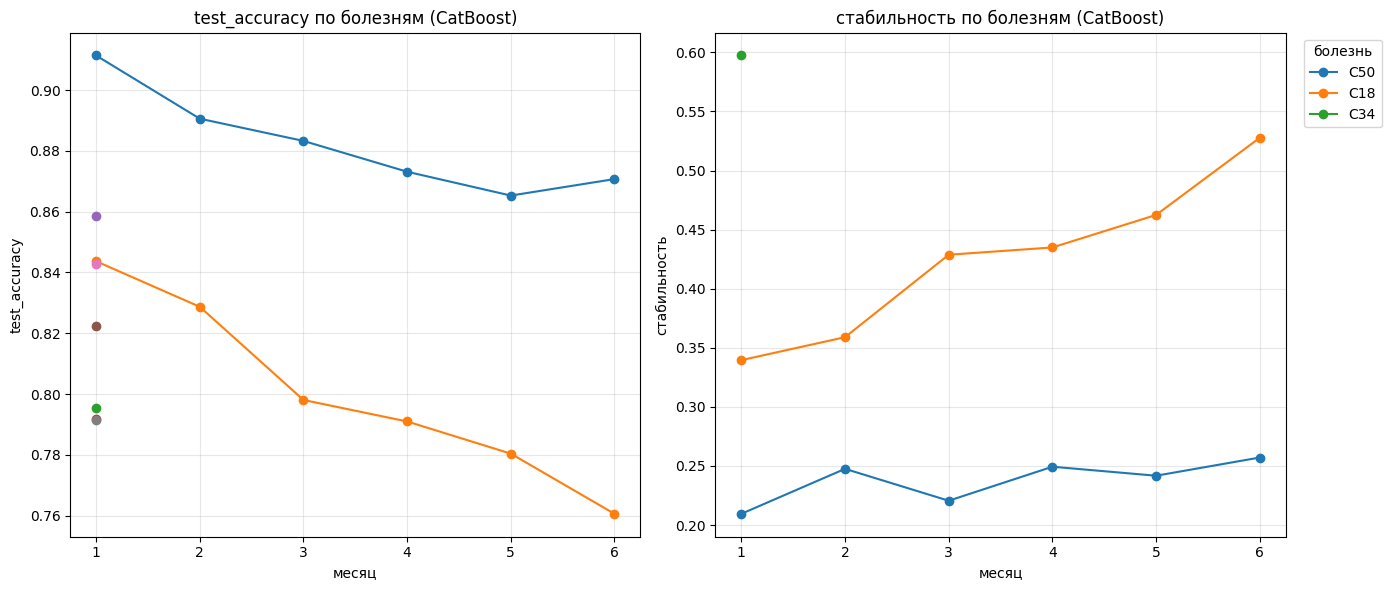

In [ ]:
diags = list(xgboost_via_diag.keys())
cmap = plt.cm.tab10
colors = {d: cmap(i % 10) for i, d in enumerate(diags)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

for diag, res in xgboost_via_diag.items():
    months = sorted(res.keys())
    vals = [np.mean([res[m][s]['test_accuracy'] for s in res[m]]) for m in months]
    ax1.plot(months, vals, marker='o', color=colors[diag], label=str(diag))
ax1.set_xlabel('месяц')
ax1.set_ylabel('test_accuracy')
ax1.set_title(f'{'test_accuracy'} по болезням (CatBoost)')
ax1.grid(True, alpha=0.3)

for diag, res in stability_via_diag.items():
    months = sorted(res.keys())
    vals = [np.mean([res[m][s] for s in res[m]]) for m in months]
    ax2.plot(months, vals, marker='o', color=colors[diag], label=str(diag))
ax2.set_xlabel('месяц')
ax2.set_ylabel('стабильность')
ax2.set_title('стабильность по болезням (CatBoost)')
ax2.grid(True, alpha=0.3)

ax2.legend(title='болезнь', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('catboost_via_diag_acc_stability.png', dpi=150)